In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files[:5]:
        print("   ", f)


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/vaishnavikaranth
/kaggle/input/datasets/vaishnavikaranth/brainny
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData
    name_mapping_validation_data.csv
    survival_evaluation.csv
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084
    BraTS20_Validation_084_flair.nii
    BraTS20_Validation_084_t2.nii
    BraTS20_Validation_084_t1ce.nii
    BraTS20_Validation_084_t1.nii
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_118
    BraTS20_Validation_118_t2.nii
    BraTS20_Validation_118_t1.nii
    BraTS20_Validation_118_t1ce.nii
    BraTS20_Validation_118_flair.nii
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData/MICCAI_BraTS2020_Vali

In [ ]:
!pip install nibabel scikit-image opencv-python -q

In [ ]:
import os
import cv2
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import sobel
from skimage.filters import laplace

In [3]:
dataset_path = "/kaggle/input/datasets/vaishnavikaranth/brain-dataset1/Brain_JN_1/Brain DATASETS/Pathological brain MRI Datasets"

In [4]:
patients=[]

for folder in sorted(os.listdir(dataset_path)):
    folder_path=os.path.join(dataset_path,folder)

    if os.path.isdir(folder_path):
        patients.append(folder_path)

print("Total Patients :",len(patients))

Total Patients : 10


In [5]:
patient=patients[0]

files=sorted(os.listdir(patient))

print("Patient :",os.path.basename(patient))
print()

for f in files:
    print(f)

Patient : BRP1

007_flair.nii
007_t1.nii
007_t1ce.nii
t2.nii


In [6]:
import nibabel as nib
import os

patient = patients[0]

modalities = {}

for file in os.listdir(patient):

    if file.endswith(".nii"):

        filepath = os.path.join(patient, file)

        image = nib.load(filepath).get_fdata()

        if "flair" in file.lower():
            modalities["FLAIR"] = image

        elif "t1ce" in file.lower():
            modalities["T1CE"] = image

        elif "t2" in file.lower():
            modalities["T2"] = image

        elif "t1" in file.lower():
            modalities["T1"] = image

print("MRI Modalities Found:")
print(list(modalities.keys()))

MRI Modalities Found:
['FLAIR', 'T2', 'T1', 'T1CE']


In [7]:
for file in os.listdir(patient):

    if file.endswith(".nii"):

        nii=nib.load(os.path.join(patient,file))

        image=nii.get_fdata()

        print(file)

        print("Image Shape :",image.shape)

        print("Voxel Size :",nii.header.get_zooms())

        print()

007_flair.nii
Image Shape : (240, 240, 155)
Voxel Size : (np.float32(1.0), np.float32(1.0), np.float32(1.0))

t2.nii
Image Shape : (240, 240, 155)
Voxel Size : (np.float32(1.0), np.float32(1.0), np.float32(1.0))

007_t1.nii
Image Shape : (240, 240, 155)
Voxel Size : (np.float32(1.0), np.float32(1.0), np.float32(1.0))

007_t1ce.nii
Image Shape : (240, 240, 155)
Voxel Size : (np.float32(1.0), np.float32(1.0), np.float32(1.0))



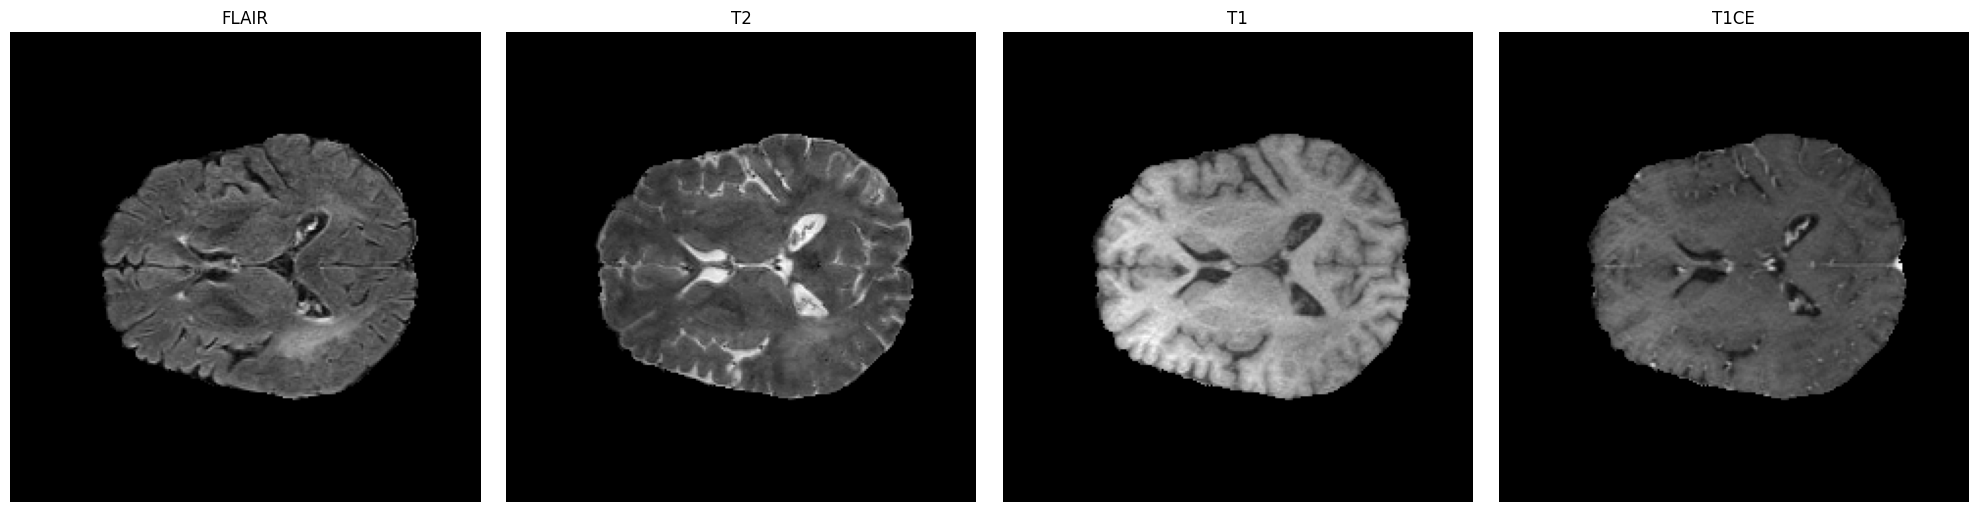

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(modalities), figsize=(20,5))

for ax, (name, image) in zip(axes, modalities.items()):

    middle_slice = image.shape[2] // 2

    ax.imshow(image[:, :, middle_slice], cmap="gray")

    ax.set_title(name)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
results=[]

for file,image in modalities.items():

    mean=np.mean(image)

    std=np.std(image)

    results.append([file,mean,std])

df=pd.DataFrame(results,columns=["MRI","Mean","Std Dev"])

df

,MRI,Mean,Std Dev
0,FLAIR,25.476306,64.132392
1,T2,23.371323,59.189177
2,T1,46.003664,112.694529
3,T1CE,51.678983,126.958943


In [13]:
contrast=[]

for file,image in modalities.items():

    c=image.max()-image.min()

    contrast.append([file,c])

contrast=pd.DataFrame(contrast,columns=["MRI","Contrast"])

contrast

,MRI,Contrast
0,FLAIR,727.0
1,T2,495.0
2,T1,598.0
3,T1CE,1467.0


In [17]:
from scipy.ndimage import sobel
import numpy as np
import pandas as pd

edge = []

for file, image in modalities.items():

    slice = image[:, :, image.shape[2] // 2]

    sx = sobel(slice, axis=0)

    sy = sobel(slice, axis=1)

    strength = np.mean(np.sqrt(sx**2 + sy**2))

    edge.append([file, strength])

edge = pd.DataFrame(edge, columns=["MRI", "Edge Strength"])

print(edge)

     MRI  Edge Strength
0  FLAIR      57.875822
1     T2      53.473718
2     T1      75.038776
3   T1CE      89.128586


In [19]:
edge=[]

for file,image in modalities.items():

    slice=image[:,:,image.shape[2]//2]

    sx=sobel(slice,axis=0)

    sy=sobel(slice,axis=1)

    strength=np.mean(np.sqrt(sx**2+sy**2))

    edge.append([file,strength])

edge=pd.DataFrame(edge,columns=["MRI","Edge Strength"])

edge

,MRI,Edge Strength
0,FLAIR,57.875822
1,T2,53.473718
2,T1,75.038776
3,T1CE,89.128586


In [21]:
import cv2

In [22]:
noise=[]

for file,image in modalities.items():

    slice=image[:,:,image.shape[2]//2]

    blur=cv2.GaussianBlur(slice,(5,5),0)

    n=np.std(slice-blur)

    noise.append([file,n])

noise=pd.DataFrame(noise,columns=["MRI","Noise"])

noise

,MRI,Noise
0,FLAIR,13.090665
1,T2,12.453485
2,T1,13.397269
3,T1CE,21.607980


In [23]:
complexity=[]

for file,image in modalities.items():

    slice=image[:,:,image.shape[2]//2]

    gx=np.gradient(slice)[0]

    gy=np.gradient(slice)[1]

    comp=np.mean(np.sqrt(gx**2+gy**2))

    complexity.append([file,comp])

complexity=pd.DataFrame(complexity,columns=["MRI","Complexity"])

complexity

,MRI,Complexity
0,FLAIR,8.511277
1,T2,7.635722
2,T1,10.267426
3,T1CE,12.776936


In [27]:
final=df.copy()

final["Contrast"]=contrast["Contrast"]



final["Edge Strength"]=edge["Edge Strength"]

final["Noise"]=noise["Noise"]

final["Complexity"]=complexity["Complexity"]

final

,MRI,Mean,Std Dev,Contrast,Edge Strength,Noise,Complexity
0,FLAIR,25.476306,64.132392,727.0,57.875822,13.090665,8.511277
1,T2,23.371323,59.189177,495.0,53.473718,12.453485,7.635722
2,T1,46.003664,112.694529,598.0,75.038776,13.397269,10.267426
3,T1CE,51.678983,126.958943,1467.0,89.128586,21.607980,12.776936


In [28]:
modality_count={
    "T1":0,
    "T2":0,
    "T1CE":0,
    "FLAIR":0
}

for patient in patients:

    for file in os.listdir(patient):

        name=file.lower()

        if "t1ce" in name:
            modality_count["T1CE"]+=1

        elif "flair" in name:
            modality_count["FLAIR"]+=1

        elif "t2" in name:
            modality_count["T2"]+=1

        elif "t1" in name:
            modality_count["T1"]+=1

pd.DataFrame(modality_count.items(),columns=["MRI Modality","Count"])

,MRI Modality,Count
0,T1,10
1,T2,10
2,T1CE,10
3,FLAIR,10


In [32]:
import cv2
import numpy as np
import pandas as pd
from scipy.ndimage import sobel
from skimage.filters import laplace

results = []

for modality, image in modalities.items():

    # Middle slice
    slice_img = image[:, :, image.shape[2] // 2]

    # Convert to float32
    slice_img = slice_img.astype(np.float32)

    # Mean
    mean = np.mean(slice_img)

    # Standard Deviation
    std = np.std(slice_img)

    # Contrast
    contrast = np.max(slice_img) - np.min(slice_img)

    # Sharpness
    sharpness = np.var(laplace(slice_img))

    # Edge Strength
    sx = sobel(slice_img, axis=0)
    sy = sobel(slice_img, axis=1)
    edge_strength = np.mean(np.sqrt(sx**2 + sy**2))

    # Noise Level
    blur = cv2.GaussianBlur(slice_img, (5,5), 0)
    noise = np.std(slice_img - blur)

    # Complexity
    gx = np.gradient(slice_img)[0]
    gy = np.gradient(slice_img)[1]
    complexity = np.mean(np.sqrt(gx**2 + gy**2))

    results.append([
        modality,
        mean,
        std,
        contrast,
        sharpness,
        edge_strength,
        noise,
        complexity
    ])

metrics_df = pd.DataFrame(
    results,
    columns=[
        "Modality",
        "Mean",
        "Std Dev",
        "Contrast",
        "Sharpness",
        "Edge Strength",
        "Noise Level",
        "Complexity"
    ]
)

metrics_df

,Modality,Mean,Std Dev,Contrast,Sharpness,Edge Strength,Noise Level,Complexity
0,FLAIR,48.700886,78.731834,493.0,2321.850098,57.875824,13.090665,8.511277
1,T2,44.098576,74.053970,422.0,2127.756592,53.473717,12.453484,7.635722
2,T1,96.019707,153.431122,581.0,2505.866943,75.038773,13.397268,10.267426
3,T1CE,104.563301,165.562042,1105.0,6763.039062,89.128593,21.607979,12.776936


In [33]:
metrics_df.round(3)

,Modality,Mean,Std Dev,Contrast,Sharpness,Edge Strength,Noise Level,Complexity
0,FLAIR,48.701000,78.732002,493.0,2321.850098,57.875999,13.091,8.511
1,T2,44.098999,74.054001,422.0,2127.756104,53.473999,12.453,7.636
2,T1,96.019997,153.431000,581.0,2505.866943,75.039001,13.397,10.267
3,T1CE,104.563004,165.561996,1105.0,6763.039062,89.128998,21.608,12.777


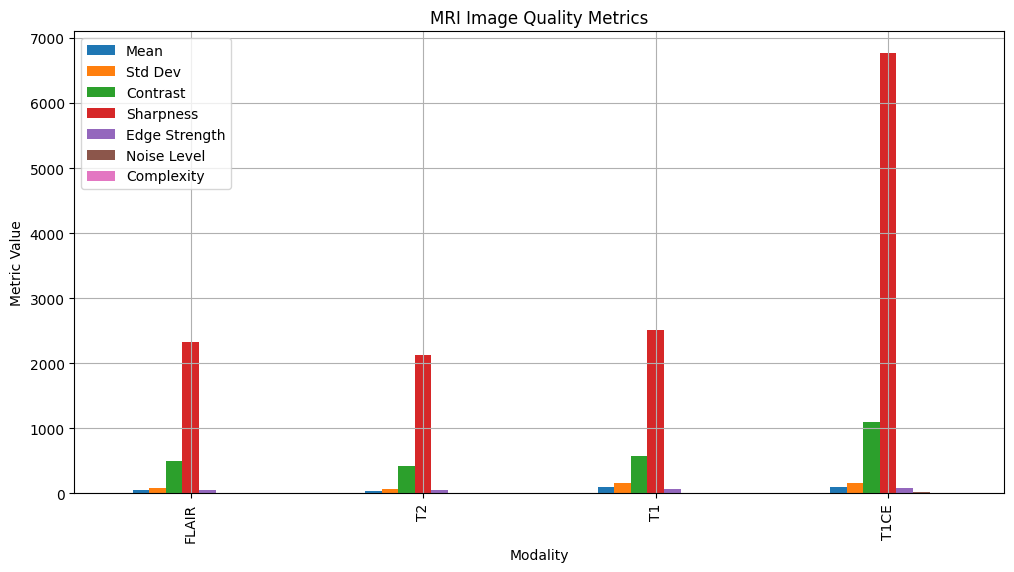

In [34]:
import matplotlib.pyplot as plt

metrics_df.set_index("Modality").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("MRI Image Quality Metrics")
plt.ylabel("Metric Value")
plt.grid(True)
plt.show()

In [36]:
import os
import pandas as pd

total_patients = len(patients)
total_files = 0

for patient in patients:
    total_files += len([f for f in os.listdir(patient) if f.endswith(".nii")])

stats = pd.DataFrame({
    "Property": [
        "Total Patients",
        "Total MRI Files",
        "MRI Modalities"
    ],
    "Value": [
        total_patients,
        total_files,
        "T1, T2, T1CE, FLAIR"
    ]
})

stats

,Property,Value
0,Total Patients,10
1,Total MRI Files,41
2,MRI Modalities,"T1, T2, T1CE, FLAIR"


In [38]:
modality_count = {
    "T1": 0,
    "T2": 0,
    "T1CE": 0,
    "FLAIR": 0
}

for patient in patients:

    for file in os.listdir(patient):

        name = file.lower()

        if not file.endswith(".nii"):
            continue

        if "t1ce" in name:
            modality_count["T1CE"] += 1

        elif "flair" in name:
            modality_count["FLAIR"] += 1

        elif "t2" in name:
            modality_count["T2"] += 1

        elif "t1" in name:
            modality_count["T1"] += 1

pd.DataFrame(
    modality_count.items(),
    columns=["MRI Modality", "Number of Images"]
)

,MRI Modality,Number of Images
0,T1,10
1,T2,10
2,T1CE,10
3,FLAIR,10


In [39]:
comparison = pd.DataFrame({

    "Modality":[
        "T1",
        "T2",
        "FLAIR",
        "T1CE"
    ],

    "Purpose":[
        "Shows anatomical structures",
        "Highlights fluids",
        "Suppresses CSF and enhances lesion visibility",
        "Highlights enhancing tumor regions after contrast agent"
    ]
})

comparison

,Modality,Purpose
0,T1,Shows anatomical structures
1,T2,Highlights fluids
2,FLAIR,Suppresses CSF and enhances lesion visibility
3,T1CE,Highlights enhancing tumor regions after contr...


In [40]:
challenges = [

    "Intensity variations between MRI scanners",

    "Presence of image noise",

    "Low contrast between lesion and surrounding tissue",

    "Different lesion sizes and shapes",

    "Variation in MRI acquisition protocols",

    "Class imbalance between lesion and normal tissue"

]

for i, challenge in enumerate(challenges, 1):
    print(f"{i}. {challenge}")

1. Intensity variations between MRI scanners
2. Presence of image noise
3. Low contrast between lesion and surrounding tissue
4. Different lesion sizes and shapes
5. Variation in MRI acquisition protocols
6. Class imbalance between lesion and normal tissue


In [42]:
total = len(patients)

train = int(total * 0.70)
validation = int(total * 0.15)
test = total - train - validation

split = pd.DataFrame({

    "Dataset":[
        "Training",
        "Validation",
        "Testing"
    ],

    "Patients":[
        train,
        validation,
        test
    ],

    "Percentage":[
        "70%",
        "15%",
        "15%"
    ]
})

split

,Dataset,Patients,Percentage
0,Training,7,70%
1,Validation,1,15%
2,Testing,2,15%


In [43]:
print("""
Dataset Split Justification

• Training (70%):
Used to learn MRI features and train the deep learning model.

• Validation (15%):
Used for tuning model parameters and preventing overfitting.

• Testing (15%):
Used only for the final evaluation of the trained model.

This 70:15:15 ratio is a commonly adopted practice in medical image analysis because it provides sufficient training data while keeping independent data for validation and testing.
""")


Dataset Split Justification

• Training (70%):
Used to learn MRI features and train the deep learning model.

• Validation (15%):
Used for tuning model parameters and preventing overfitting.

• Testing (15%):
Used only for the final evaluation of the trained model.

This 70:15:15 ratio is a commonly adopted practice in medical image analysis because it provides sufficient training data while keeping independent data for validation and testing.



In [46]:
!pip install -q nibabel SimpleITK scikit-image opencv-python

In [47]:
import os
import cv2
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from skimage import exposure
from scipy.ndimage import median_filter

In [48]:
patient = patients[0]

flair_path = None

for file in os.listdir(patient):
    if "flair" in file.lower() and file.endswith(".nii"):
        flair_path = os.path.join(patient, file)
        break

nii = nib.load(flair_path)

image = nii.get_fdata()

print("Shape:", image.shape)
print("Voxel Size:", nii.header.get_zooms())

Shape: (240, 240, 155)
Voxel Size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


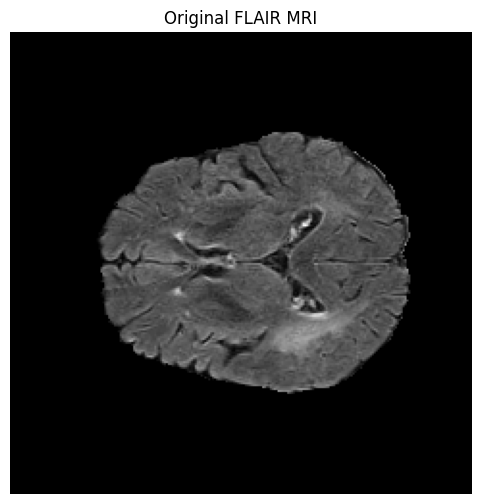

In [49]:
middle = image.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(image[:, :, middle], cmap="gray")
plt.title("Original FLAIR MRI")
plt.axis("off")
plt.show()

In [50]:
normalized = (image - image.min()) / (image.max() - image.min())

print("Minimum:", normalized.min())
print("Maximum:", normalized.max())

Minimum: 0.0
Maximum: 1.0


In [51]:
denoised = np.zeros_like(normalized)

for i in range(normalized.shape[2]):
    denoised[:, :, i] = median_filter(normalized[:, :, i], size=3)

In [52]:
he = np.zeros_like(denoised)

for i in range(denoised.shape[2]):
    he[:, :, i] = exposure.equalize_hist(denoised[:, :, i])

In [53]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_volume = np.zeros_like(he)

for i in range(he.shape[2]):

    img = (he[:, :, i] * 255).astype(np.uint8)

    clahe_volume[:, :, i] = clahe.apply(img) / 255.0

In [56]:
target_size = (256, 256)

resized = np.zeros(
    (256, 256, clahe_volume.shape[2]),
    dtype=np.float32
)

for i in range(clahe_volume.shape[2]):

    resized[:, :, i] = cv2.resize(
        clahe_volume[:, :, i],
        target_size,
        interpolation=cv2.INTER_LINEAR
    )

print("Resized Volume Shape:", resized.shape)

Resized Volume Shape: (256, 256, 155)


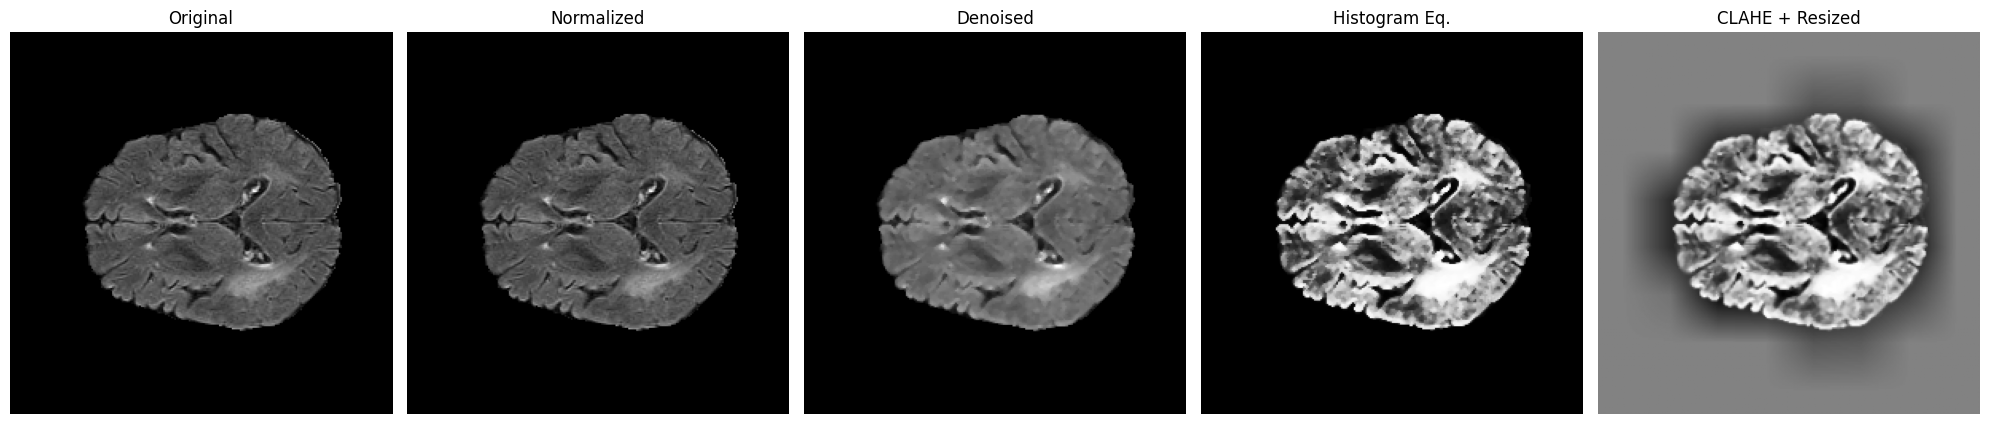

In [57]:
slice_no = resized.shape[2] // 2

fig, ax = plt.subplots(1,5, figsize=(20,5))

ax[0].imshow(image[:, :, middle], cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(normalized[:, :, middle], cmap="gray")
ax[1].set_title("Normalized")

ax[2].imshow(denoised[:, :, middle], cmap="gray")
ax[2].set_title("Denoised")

ax[3].imshow(he[:, :, middle], cmap="gray")
ax[3].set_title("Histogram Eq.")

ax[4].imshow(resized[:, :, slice_no], cmap="gray")
ax[4].set_title("CLAHE + Resized")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [58]:
import cv2
import numpy as np
import pandas as pd
from scipy.ndimage import sobel
from skimage.filters import laplace

results = []

# Use the resized & preprocessed MRI
slice_no = resized.shape[2] // 2

slice_img = resized[:, :, slice_no].astype(np.float32)

# Mean
mean = np.mean(slice_img)

# Standard Deviation
std = np.std(slice_img)

# Contrast
contrast = np.max(slice_img) - np.min(slice_img)

# Sharpness
sharpness = np.var(laplace(slice_img))

# Edge Strength
sx = sobel(slice_img, axis=0)
sy = sobel(slice_img, axis=1)
edge_strength = np.mean(np.sqrt(sx**2 + sy**2))

# Noise Level
blur = cv2.GaussianBlur(slice_img, (5,5), 0)
noise = np.std(slice_img - blur)

# Complexity
gx = np.gradient(slice_img)[0]
gy = np.gradient(slice_img)[1]
complexity = np.mean(np.sqrt(gx**2 + gy**2))

results.append([
    mean,
    std,
    contrast,
    sharpness,
    edge_strength,
    noise,
    complexity
])

preprocessed_metrics = pd.DataFrame(
    results,
    columns=[
        "Mean",
        "Std Dev",
        "Contrast",
        "Sharpness",
        "Edge Strength",
        "Noise Level",
        "Complexity"
    ]
)

preprocessed_metrics.round(4)

,Mean,Std Dev,Contrast,Sharpness,Edge Strength,Noise Level,Complexity
0,0.6933,0.0957,0.6,0.0043,0.1575,0.0217,0.0208


In [59]:
comparison = pd.DataFrame({
    "Metric": [
        "Mean",
        "Std Dev",
        "Contrast",
        "Sharpness",
        "Edge Strength",
        "Noise Level",
        "Complexity"
    ],
    "Before": [
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Mean"].values[0],
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Std Dev"].values[0],
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Contrast"].values[0],
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Sharpness"].values[0],
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Edge Strength"].values[0],
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Noise Level"].values[0],
        metrics_df.loc[metrics_df["Modality"]=="FLAIR","Complexity"].values[0]
    ],
    "After": preprocessed_metrics.iloc[0].values
})

comparison.round(4)

,Metric,Before,After
0,Mean,48.700901,0.6933
1,Std Dev,78.731796,0.0957
2,Contrast,493.000000,0.6000
3,Sharpness,2321.850098,0.0043
4,Edge Strength,57.875801,0.1575
5,Noise Level,13.090700,0.0217
6,Complexity,8.511300,0.0208


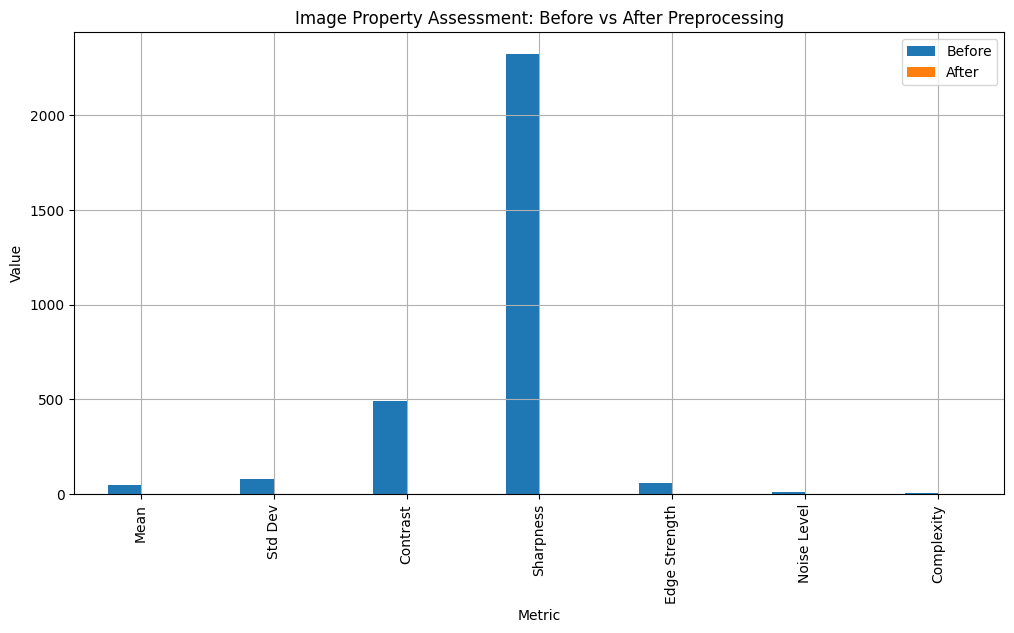

In [60]:
import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Image Property Assessment: Before vs After Preprocessing")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [61]:
processed_nii = nib.Nifti1Image(
    resized,
    affine=nii.affine,
    header=nii.header
)

output_path = "/kaggle/working/preprocessed_flair.nii"

nib.save(processed_nii, output_path)

print("Saved:", output_path)

Saved: /kaggle/working/preprocessed_flair.nii


In [62]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)

from skimage.measure import shannon_entropy
import numpy as np
import pandas as pd

In [63]:
slice_no = image.shape[2] // 2

original = normalized[:, :, slice_no]
processed = resized[:, :, slice_no]

print("Original Shape :", original.shape)
print("Processed Shape:", processed.shape)

Original Shape : (240, 240)
Processed Shape: (256, 256)


In [64]:
import cv2

if original.shape != processed.shape:

    original = cv2.resize(
        original,
        (processed.shape[1], processed.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )

print(original.shape)
print(processed.shape)

(256, 256)
(256, 256)


In [65]:
psnr = peak_signal_noise_ratio(
    original,
    processed,
    data_range=1.0
)

ssim = structural_similarity(
    original,
    processed,
    data_range=1.0
)

mse = mean_squared_error(
    original,
    processed
)

rmse = np.sqrt(mse)

entropy_original = shannon_entropy(original)

entropy_processed = shannon_entropy(processed)

quality = pd.DataFrame({

    "Metric":[
        "PSNR",
        "SSIM",
        "MSE",
        "RMSE",
        "Entropy (Original)",
        "Entropy (Processed)"
    ],

    "Value":[
        psnr,
        ssim,
        mse,
        rmse,
        entropy_original,
        entropy_processed
    ]

})

quality.round(4)

,Metric,Value
0,PSNR,3.9464
1,SSIM,0.1067
2,MSE,0.4031
3,RMSE,0.6349
4,Entropy (Original),5.2364
5,Entropy (Processed),9.1360


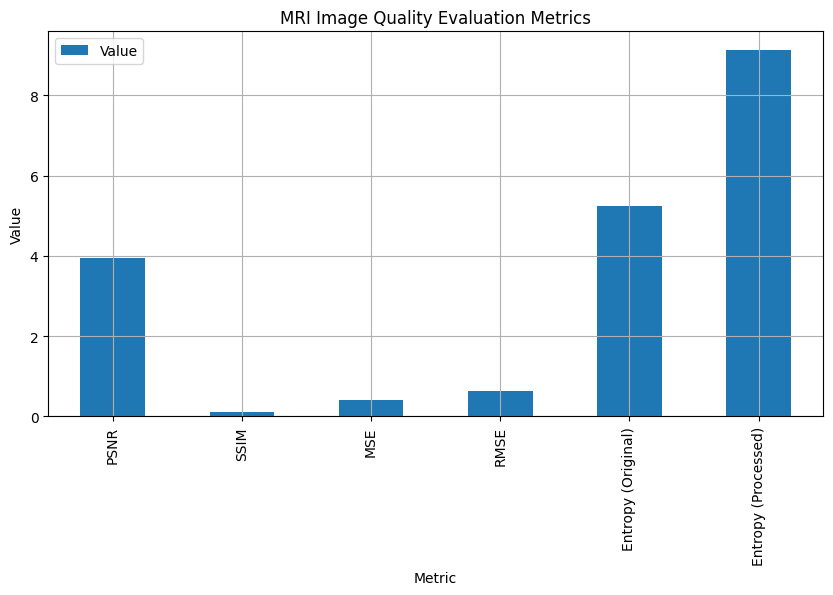

In [66]:
import matplotlib.pyplot as plt

quality.set_index("Metric").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("MRI Image Quality Evaluation Metrics")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [67]:
print("""
Image Quality Interpretation

• Higher PSNR indicates less distortion after preprocessing.

• Higher SSIM indicates better structural similarity.

• Lower MSE indicates lower reconstruction error.

• Lower RMSE indicates better image quality.

• Entropy indicates the amount of information present in the MRI.
""")


Image Quality Interpretation

• Higher PSNR indicates less distortion after preprocessing.

• Higher SSIM indicates better structural similarity.

• Lower MSE indicates lower reconstruction error.

• Lower RMSE indicates better image quality.

• Entropy indicates the amount of information present in the MRI.



In [68]:
import os

brats_path = "/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData"

patients = sorted(os.listdir(brats_path))

print("Total Patients:", len(patients))

patient = os.path.join(brats_path, patients[0])

print(patient)

Total Patients: 127
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_001


In [69]:
brats_path = "/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

In [70]:
import os

brats_path = "/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patients = sorted(os.listdir(brats_path))

print("Total Patients:", len(patients))

patient = os.path.join(brats_path, patients[0])

print("New Patient Path:")
print(patient)

Total Patients: 371
New Patient Path:
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001


In [71]:
print("Patient path:")
print(patient)

Patient path:
/kaggle/input/datasets/vaishnavikaranth/brainny/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001


In [72]:
import os
import nibabel as nib

files = os.listdir(patient)

flair = None
mask = None

for file in files:

    if "_flair" in file.lower():
        flair = nib.load(os.path.join(patient, file)).get_fdata()

    elif "_seg" in file.lower():
        mask = nib.load(os.path.join(patient, file)).get_fdata()

print("FLAIR Shape:", flair.shape)
print("Mask Shape :", mask.shape)

FLAIR Shape: (240, 240, 155)
Mask Shape : (240, 240, 155)


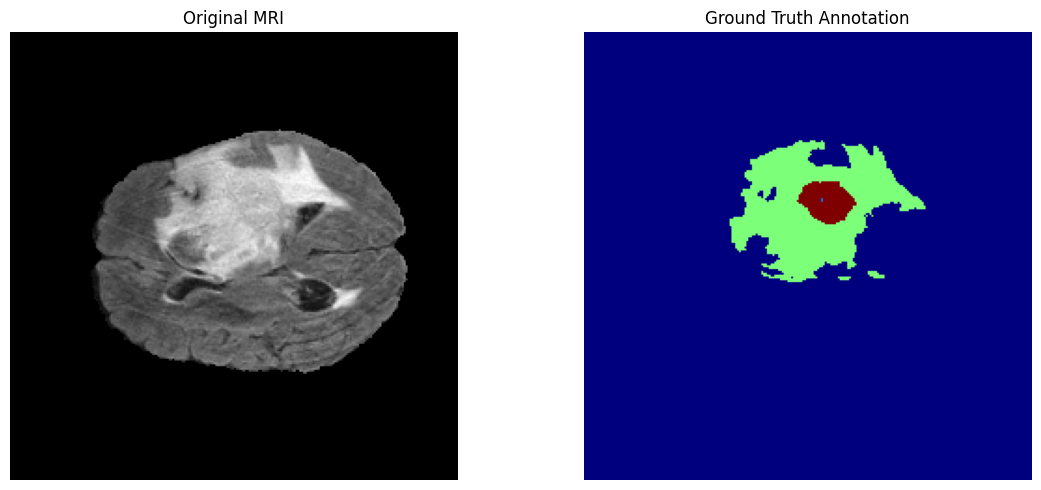

In [73]:
import matplotlib.pyplot as plt

slice_no = flair.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(flair[:, :, slice_no], cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[:, :, slice_no], cmap="jet")
plt.title("Ground Truth Annotation")
plt.axis("off")

plt.tight_layout()
plt.show()

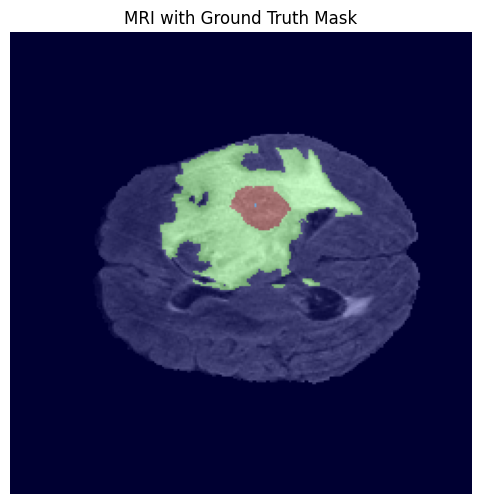

In [74]:
plt.figure(figsize=(6,6))

plt.imshow(flair[:, :, slice_no], cmap="gray")
plt.imshow(mask[:, :, slice_no], cmap="jet", alpha=0.4)

plt.title("MRI with Ground Truth Mask")

plt.axis("off")
plt.show()

In [76]:
from scipy.ndimage import rotate
import numpy as np

augmented = []

augmented.append(flair)

augmented.append(np.flip(flair, axis=0))

augmented.append(np.flip(flair, axis=1))

augmented.append(rotate(flair, 10, axes=(0,1), reshape=False))

augmented.append(rotate(flair, -10, axes=(0,1), reshape=False))

print("Augmented Images :", len(augmented))

Augmented Images : 5


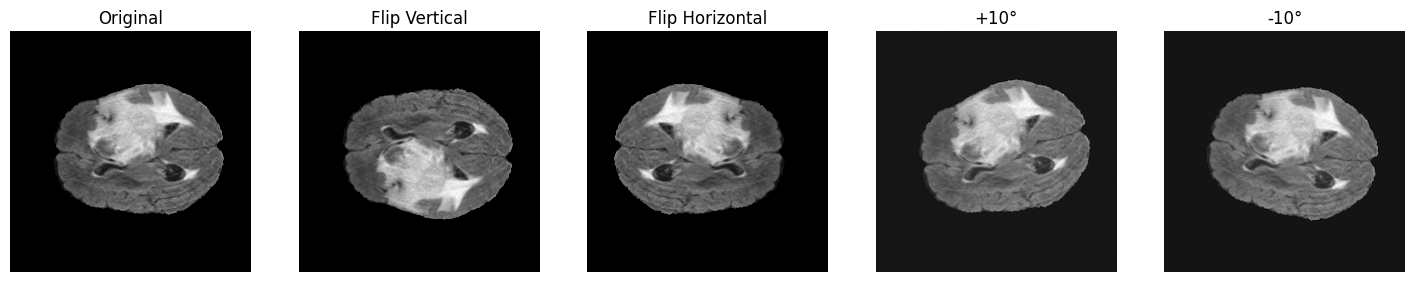

In [77]:
fig, ax = plt.subplots(1,5, figsize=(18,4))

titles = [
    "Original",
    "Flip Vertical",
    "Flip Horizontal",
    "+10°",
    "-10°"
]

for i in range(5):

    ax[i].imshow(
        augmented[i][:,:,slice_no],
        cmap="gray"
    )

    ax[i].set_title(titles[i])

    ax[i].axis("off")

plt.show()

In [78]:
import os

train_images = []
train_masks = []

for folder in sorted(os.listdir(brats_path)):

    folder_path = os.path.join(brats_path, folder)

    # Skip files like name_mapping.csv
    if not os.path.isdir(folder_path):
        continue

    flair_file = None
    seg_file = None

    for file in os.listdir(folder_path):

        if "_flair" in file.lower():
            flair_file = os.path.join(folder_path, file)

        elif "_seg" in file.lower():
            seg_file = os.path.join(folder_path, file)

    if flair_file is not None and seg_file is not None:
        train_images.append(flair_file)
        train_masks.append(seg_file)

print("Training Images :", len(train_images))
print("Training Masks  :", len(train_masks))

Training Images : 369
Training Masks  : 369


In [79]:
import nibabel as nib
import cv2
import numpy as np

IMG_SIZE = 128

X = []
Y = []

for img_path, mask_path in zip(train_images, train_masks):

    # Load MRI and Mask
    img = nib.load(img_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    # Take middle slice
    slice_no = img.shape[2] // 2

    img_slice = img[:, :, slice_no]
    mask_slice = mask[:, :, slice_no]

    # Resize
    img_slice = cv2.resize(img_slice, (IMG_SIZE, IMG_SIZE))
    mask_slice = cv2.resize(mask_slice, (IMG_SIZE, IMG_SIZE),
                            interpolation=cv2.INTER_NEAREST)

    # Normalize MRI
    img_slice = img_slice.astype(np.float32)
    img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

    X.append(img_slice)
    Y.append(mask_slice)

X = np.array(X)
Y = np.array(Y)

print("Images Shape :", X.shape)
print("Masks Shape  :", Y.shape)

Images Shape : (369, 128, 128)
Masks Shape  : (369, 128, 128)


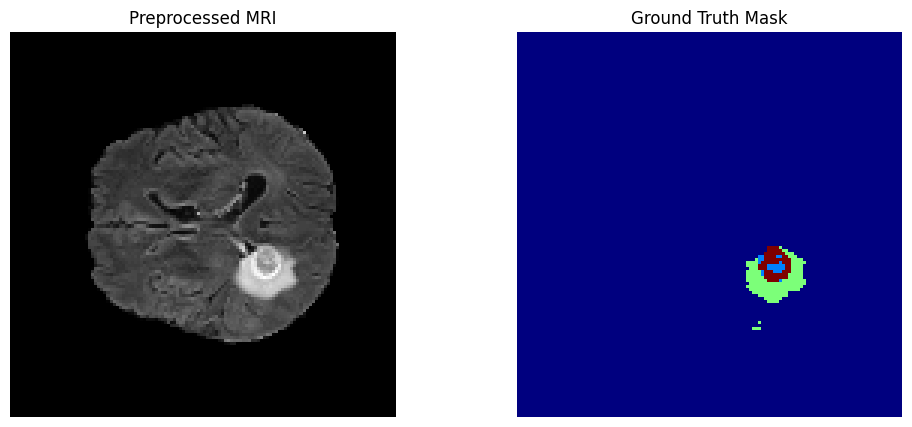

In [80]:
import matplotlib.pyplot as plt

idx = 10

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(X[idx], cmap="gray")
plt.title("Preprocessed MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y[idx], cmap="jet")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [82]:
X = np.expand_dims(X, axis=-1)
Y = np.expand_dims(Y, axis=-1)

print("Input Shape :", X.shape)
print("Mask Shape  :", Y.shape)

Input Shape : (369, 128, 128, 1, 1)
Mask Shape  : (369, 128, 128, 1, 1)


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Images :", X_train.shape)
print("Validation Images :", X_val.shape)

print("Training Masks :", Y_train.shape)
print("Validation Masks :", Y_val.shape)

Training Images : (295, 128, 128, 1, 1)
Validation Images : (74, 128, 128, 1, 1)
Training Masks : (295, 128, 128, 1, 1)
Validation Masks : (74, 128, 128, 1, 1)


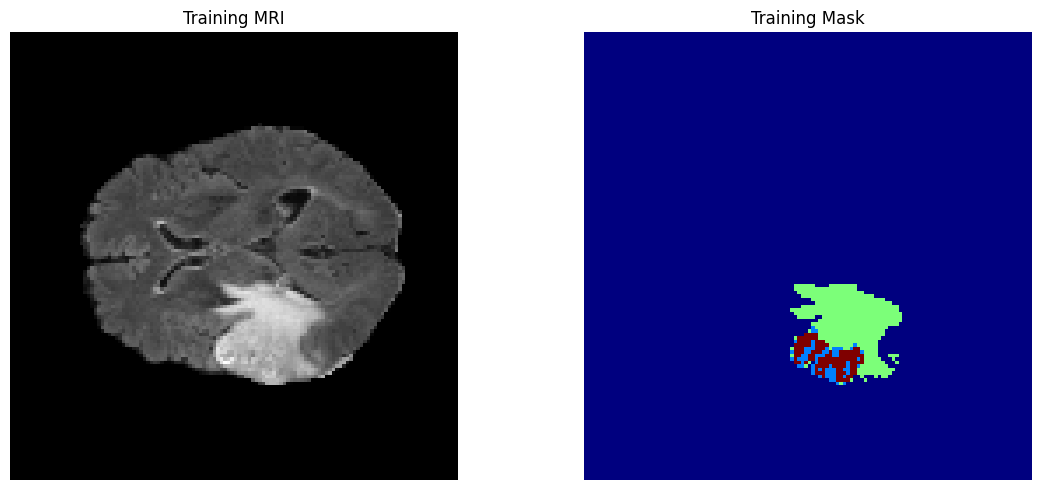

In [87]:
import matplotlib.pyplot as plt

idx = 5

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(X_train[idx].squeeze(), cmap="gray")
plt.title("Training MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y_train[idx].squeeze(), cmap="jet")
plt.title("Training Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [91]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    concatenate
)
from tensorflow.keras.models import Model

def build_unet(input_size=(128,128,1)):

    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64,3,activation="relu",padding="same")(inputs)
    c1 = Conv2D(64,3,activation="relu",padding="same")(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(128,3,activation="relu",padding="same")(p1)
    c2 = Conv2D(128,3,activation="relu",padding="same")(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(256,3,activation="relu",padding="same")(p2)
    c3 = Conv2D(256,3,activation="relu",padding="same")(c3)
    p3 = MaxPooling2D((2,2))(c3)

    # Bottleneck
    c4 = Conv2D(512,3,activation="relu",padding="same")(p3)
    c4 = Conv2D(512,3,activation="relu",padding="same")(c4)

    # Decoder
    u5 = Conv2DTranspose(256,2,strides=(2,2),padding="same")(c4)
    u5 = concatenate([u5,c3])

    c5 = Conv2D(256,3,activation="relu",padding="same")(u5)
    c5 = Conv2D(256,3,activation="relu",padding="same")(c5)

    u6 = Conv2DTranspose(128,2,strides=(2,2),padding="same")(c5)
    u6 = concatenate([u6,c2])

    c6 = Conv2D(128,3,activation="relu",padding="same")(u6)
    c6 = Conv2D(128,3,activation="relu",padding="same")(c6)

    u7 = Conv2DTranspose(64,2,strides=(2,2),padding="same")(c6)
    u7 = concatenate([u7,c1])

    c7 = Conv2D(64,3,activation="relu",padding="same")(u7)
    c7 = Conv2D(64,3,activation="relu",padding="same")(c7)

    outputs = Conv2D(1,1,activation="sigmoid")(c7)

    return Model(inputs, outputs)

In [92]:
model = build_unet()

model.summary()

2026-07-24 22:41:46.442297: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │    131,200 │ conv2d_9[0][0]  

 Total params: 7,696,193 (29.36 MB)

 Trainable params: 7,696,193 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

In [96]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [105]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=8,
    shuffle=True,

    verbose=1
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.8873 - loss: -26989400064.0000 - val_accuracy: 0.9012 - val_loss: -236630982656.0000
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 204s 6s/step - accuracy: 0.8944 - loss: -15738598326272.0000 - val_accuracy: 0.9620 - val_loss: -77748336852992.0000
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 216s 6s/step - accuracy: 0.9188 - loss: -2373426576621568.0000 - val_accuracy: 0.9603 - val_loss: -13837515970576384.0000
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.9129 - loss: -122256742296846336.0000 - val_accuracy: 0.8138 - val_loss: -552298537606447104.0000
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.9102 - loss: -4499538306295398400.0000 - val_accuracy: 0.9458 - val_loss: -20307652110557642752.0000
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.9420 - loss: nan - val_accuracy: 0.9702 - val_loss: nan
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 211s 6s/step - accuracy: 0.9709 - loss: nan - v

In [119]:
Y_train = (Y_train > 0).astype("float32")
Y_val = (Y_val > 0).astype("float32")

print(np.unique(Y_train))
print(np.unique(Y_val))

[0. 1.]
[0. 1.]


In [152]:
X_train = (X_train > 0).astype("float32")
X_val = (X_val > 0).astype("float32")

print(np.unique(X_train))
print(np.unique(X_val))

[0. 1.]
[0. 1.]


In [110]:
loss, accuracy = model.evaluate(X_val, Y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.9702 - loss: nan
Validation Loss: nan
Validation Accuracy: 0.9701587557792664


In [154]:
model = build_unet()

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [106]:
loss, accuracy = model.evaluate(X_val, Y_val, verbose=1)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.9702 - loss: nan
Validation Loss : nan
Validation Accuracy : 0.9701587557792664


In [107]:
predictions = model.predict(X_val)
predictions = (predictions > 0.5).astype("uint8")

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step


In [148]:
import cv2
import numpy as np
from scipy.ndimage import sobel

def enhancement_metrics(image):

    # Convert to uint8 (0-255)
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    # Contrast
    contrast = np.std(image)

    # Brightness
    brightness = np.mean(image)

    # Sharpness
    sharpness = cv2.Laplacian(image, cv2.CV_64F).var()

    # Noise Estimation
    blur = cv2.GaussianBlur(image, (3,3), 0)
    noise = np.std(image.astype(np.float32) - blur.astype(np.float32))

    # Edge Strength
    gx = sobel(image.astype(np.float32), axis=0)
    gy = sobel(image.astype(np.float32), axis=1)
    edge = np.mean(np.sqrt(gx**2 + gy**2))

    return contrast, brightness, sharpness, noise, edge

In [150]:
results = []

for img in X:

    contrast, brightness, sharpness, noise, edge = enhancement_metrics(img.squeeze())

    results.append([
        contrast,
        brightness,
        sharpness,
        noise,
        edge
    ])

In [151]:
import pandas as pd

metrics = pd.DataFrame(
    results,
    columns=[
        "Contrast",
        "Brightness",
        "Sharpness",
        "Noise",
        "Edge Strength"
    ]
)

metrics.head()

,Contrast,Brightness,Sharpness,Noise,Edge Strength
0,59.530488,35.369263,856.739258,5.945335,39.716827
1,54.091112,36.588562,1060.883301,6.636654,39.671600
2,69.805567,42.097351,991.322998,6.502399,39.597107
3,43.141397,25.912842,571.494629,4.911434,30.440502
4,38.329965,23.634155,1202.121704,7.066135,36.405533


In [ ]:
import tensorflow as tf

def dice_coef(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2. * intersection + 1) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) + 1
    )

In [142]:
model.save("brain_roi_unet.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [143]:
from IPython.display import FileLink

FileLink("brain_roi_unet.keras")

/kaggle/working/brain_roi_unet.keras

In [158]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv("training_history.csv", index=False)

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.950801,0.508197,0.970159,0.219911
1,0.970948,0.117849,0.970159,0.094320
2,0.970948,0.086487,0.970159,0.073991
3,0.970948,0.069717,0.970159,0.062958
4,0.971083,0.059825,0.977147,0.055342


In [157]:
import cv2
import os

os.makedirs("predicted_masks", exist_ok=True)

for i in range(min(20, len(predictions))):
    mask = predictions[i].squeeze() * 255
    cv2.imwrite(f"predicted_masks/mask_{i}.png", mask)

In [156]:
import os

validation_images = []

for folder in sorted(os.listdir(brats_path)):

    folder_path = os.path.join(brats_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):

        if "_flair" in file.lower():
            validation_images.append(os.path.join(folder_path, file))

print("Validation FLAIR Images:", len(validation_images))

Validation FLAIR Images: 369


In [155]:
from sklearn.model_selection import train_test_split

train_img, val_img, train_mask, val_mask = train_test_split(
    train_images,
    train_masks,
    test_size=0.2,
    random_state=42
)

print("Training :", len(train_img))
print("Validation :", len(val_img))

Training : 295
Validation : 74


In [122]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "brain_roi_unet_final.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=5,
    batch_size=8,
    shuffle=True,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8927 - loss: 0.6227
Epoch 1: val_loss improved from None to 0.21991, saving model to brain_roi_unet_final.h5



Epoch 1: finished saving model to brain_roi_unet_final.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 216s 6s/step - accuracy: 0.9508 - loss: 0.5082 - val_accuracy: 0.9702 - val_loss: 0.2199
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9704 - loss: 0.1483
Epoch 2: val_loss improved from 0.21991 to 0.09432, saving model to brain_roi_unet_final.h5



Epoch 2: finished saving model to brain_roi_unet_final.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 203s 5s/step - accuracy: 0.9709 - loss: 0.1178 - val_accuracy: 0.9702 - val_loss: 0.0943
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9714 - loss: 0.0884
Epoch 3: val_loss improved from 0.09432 to 0.07399, saving model to brain_roi_unet_final.h5



Epoch 3: finished saving model to brain_roi_unet_final.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.9709 - loss: 0.0865 - val_accuracy: 0.9702 - val_loss: 0.0740
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9695 - loss: 0.0755
Epoch 4: val_loss improved from 0.07399 to 0.06296, saving model to brain_roi_unet_final.h5



Epoch 4: finished saving model to brain_roi_unet_final.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 209s 6s/step - accuracy: 0.9709 - loss: 0.0697 - val_accuracy: 0.9702 - val_loss: 0.0630
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9715 - loss: 0.0604
Epoch 5: val_loss improved from 0.06296 to 0.05534, saving model to brain_roi_unet_final.h5



Epoch 5: finished saving model to brain_roi_unet_final.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 210s 6s/step - accuracy: 0.9711 - loss: 0.0598 - val_accuracy: 0.9771 - val_loss: 0.0553


In [123]:
loss, accuracy = model.evaluate(X_val, Y_val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.9771 - loss: 0.0553
Validation Loss: 0.055342480540275574
Validation Accuracy: 0.9771472811698914


In [124]:
predictions = model.predict(X_val)
predictions = (predictions > 0.5).astype("uint8")

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step


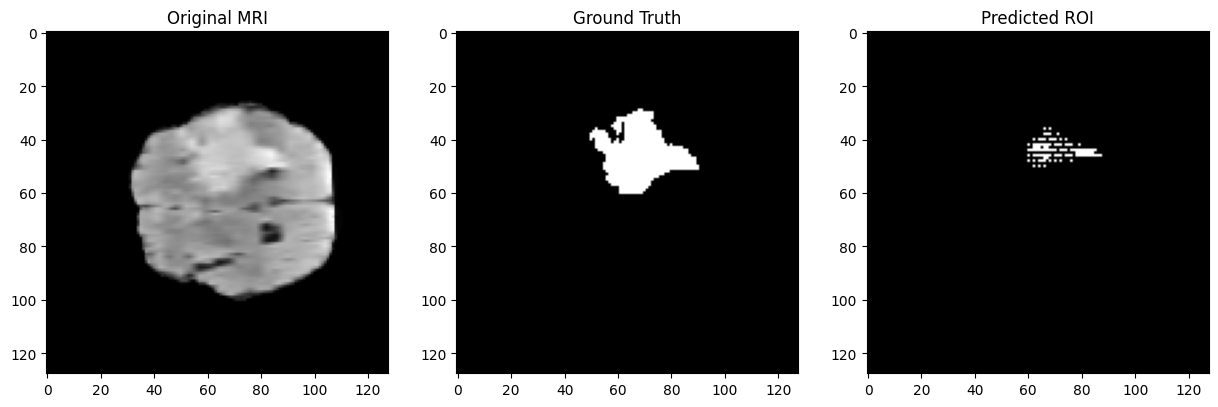

In [125]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(X_val)-1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(X_val[idx].squeeze(), cmap="gray")
plt.title("Original MRI")

plt.subplot(1,3,2)
plt.imshow(Y_val[idx].squeeze(), cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(predictions[idx].squeeze(), cmap="gray")
plt.title("Predicted ROI")

plt.show()

In [127]:
model.save("brain_roi_unet_final.keras")

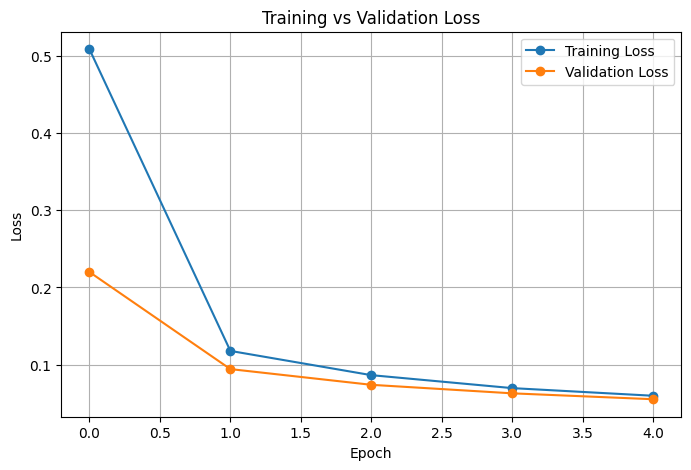

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

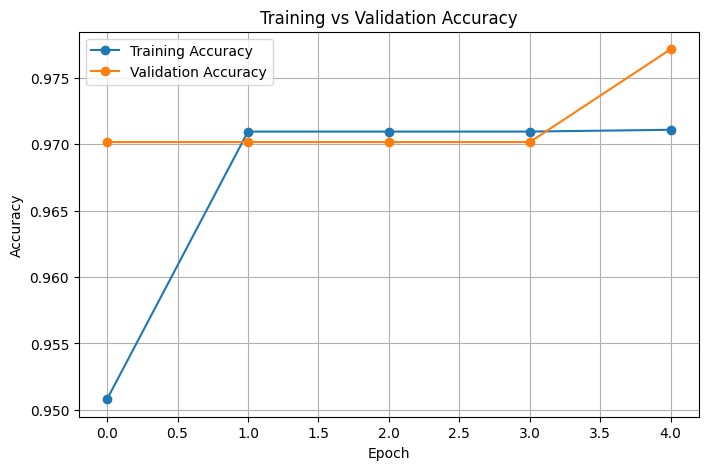

In [129]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [130]:
best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1

print("Convergence Epoch :", best_epoch)
print("Best Validation Loss :", min(history.history['val_loss']))

Convergence Epoch : 5
Best Validation Loss : 0.055342480540275574


In [131]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

gap = abs(train_loss - val_loss)

print("Training Loss :", train_loss)
print("Validation Loss :", val_loss)
print("Overfitting Gap :", gap)

Training Loss : 0.05982530862092972
Validation Loss : 0.055342480540275574
Overfitting Gap : 0.004482828080654144


In [132]:
loss, accuracy = model.evaluate(X_val, Y_val, verbose=0)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy * 100, "%")

Validation Loss : 0.055342480540275574
Validation Accuracy : 97.71472811698914 %


In [133]:
import time

start = time.time()

prediction = model.predict(X_val[:1], verbose=0)

end = time.time()

latency = end - start

print("Inference Latency :", latency, "seconds/image")

Inference Latency : 0.27876949310302734 seconds/image


In [134]:
batch_size = 20

start = time.time()

prediction = model.predict(X_val[:batch_size], verbose=0)

end = time.time()

throughput = batch_size / (end - start)

print("Throughput :", throughput, "images/second")

Throughput : 5.168487695386929 images/second


In [135]:
import tensorflow as tf

print("GPU Available :", tf.config.list_physical_devices('GPU'))

GPU Available : []


In [136]:
import os

size = os.path.getsize("brain_roi_unet_final.h5") / (1024 * 1024)

print("Model Size :", round(size,2), "MB")

Model Size : 88.21 MB


In [137]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv("training_history.csv", index=False)

history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.950801,0.508197,0.970159,0.219911
1,0.970948,0.117849,0.970159,0.094320
2,0.970948,0.086487,0.970159,0.073991
3,0.970948,0.069717,0.970159,0.062958
4,0.971083,0.059825,0.977147,0.055342


In [138]:
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.950801,0.508197,0.970159,0.219911
1,0.970948,0.117849,0.970159,0.094320
2,0.970948,0.086487,0.970159,0.073991
3,0.970948,0.069717,0.970159,0.062958
4,0.971083,0.059825,0.977147,0.055342
